# Plane Least Squares fit function Testing  

**Purpose**: Code for testing the plane least squares fit functions on fake data

**Luke Colosi | lcolosi@ucsd.edu**

Force matplotlib plots to display directly within the output cell of the notebook: 

In [1]:
%matplotlib inline


Import python libraries


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import cmocean.cm as cmo

In [3]:
def plane_lsf(data, xcor, ycor, parameters, sigma):
    """
    Function for computing a plane fit to 2D data of order n using least squares.

    Parameters
    ----------
    data : 2D array
        Data field (may contain NaN values).
    xcor, ycor : 2D arrays
        Coordinate matrices (same shape as data).
    parameters : int
        Order of polynomial fit (0, 1, 2, or 3).
    sigma : float
        Measurement uncertainty (currently scalar).

    Returns
    -------
    plane_fit : 2D array
        Best-fit plane evaluated at all (x, y) points.
    x_data : 1D array
        Model coefficients.
    x_data_sigma : 1D array
        Standard deviation (uncertainty) of model coefficients.
    L2_norm : float
        L2 norm of the residuals between model and data.
    """

    # Import library 
    import numpy as np
    
    # Dimensions
    nx, ny = data.shape

    # Mask NaNs
    mask = ~np.isnan(data)
    data_flat = data[mask].ravel()
    x_flat = xcor[mask].ravel()
    y_flat = ycor[mask].ravel()

    # --- Build design matrix A depending on polynomial order ---
    if parameters == 0:
        A = np.ones((len(data_flat), 1))
    elif parameters == 1:
        A = np.column_stack((np.ones_like(x_flat), x_flat, y_flat))
    elif parameters == 2:
        A = np.column_stack((np.ones_like(x_flat), x_flat, y_flat,
                             x_flat**2, x_flat*y_flat, y_flat**2))
    elif parameters == 3:
        A = np.column_stack((np.ones_like(x_flat), x_flat, y_flat,
                             x_flat**2, x_flat*y_flat, y_flat**2,
                             x_flat**3, (x_flat**2)*y_flat,
                             x_flat*(y_flat**2), y_flat**3))
    else:
        raise ValueError("parameters must be 0, 1, 2, or 3")

    # --- Least squares fit (Ax = b) ---
    # Solve using normal equations (consistent with MATLAB version)
    ATA_inv = np.linalg.inv(A.T @ A)
    x_data = ATA_inv @ A.T @ data_flat

    # --- Compute fitted surface ---
    if parameters == 0:
        hfit = x_data[0] * np.ones(nx * ny)
    elif parameters == 1:
        hfit = (x_data[0]
                + x_data[1]*xcor.ravel()
                + x_data[2]*ycor.ravel())
    elif parameters == 2:
        hfit = (x_data[0]
                + x_data[1]*xcor.ravel()
                + x_data[2]*ycor.ravel()
                + x_data[3]*xcor.ravel()**2
                + x_data[4]*xcor.ravel()*ycor.ravel()
                + x_data[5]*ycor.ravel()**2)
    elif parameters == 3:
        hfit = (x_data[0]
                + x_data[1]*xcor.ravel()
                + x_data[2]*ycor.ravel()
                + x_data[3]*xcor.ravel()**2
                + x_data[4]*xcor.ravel()*ycor.ravel()
                + x_data[5]*ycor.ravel()**2
                + x_data[6]*xcor.ravel()**3
                + x_data[7]*(xcor.ravel()**2)*ycor.ravel()
                + x_data[8]*xcor.ravel()*(ycor.ravel()**2)
                + x_data[9]*ycor.ravel()**3)

    # Reshape back to 2D
    plane_fit = hfit.reshape((nx, ny))

    # --- Covariance matrix and coefficient uncertainties ---
    # (σ^2) * (AᵀA)⁻¹ is the standard least-squares covariance
    C = (sigma**2) * ATA_inv
    x_data_sigma = np.sqrt(np.diag(C))

    # --- L2 norm of residuals ---
    residuals = A @ x_data - data_flat
    L2_norm = np.sqrt(np.sum(np.abs(residuals)**2))

    return plane_fit, x_data, x_data_sigma, L2_norm


Test function

True coefficients: [3.0, 2.0, -1.5, 0.5, -0.2, 0.3]
Estimated coefficients: [ 2.996  2.011 -1.497  0.499 -0.195  0.3  ]
Uncertainties (σ): [0.02  0.009 0.009 0.009 0.008 0.009]
L2 Norm of residuals: 23.031


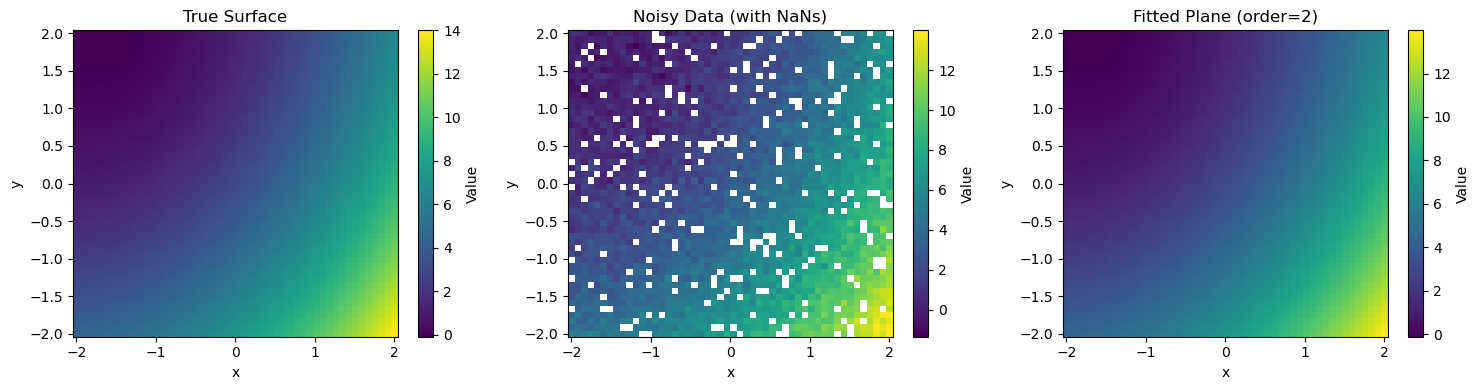

In [5]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------------------------------------
# Import or paste your plane_lsf() function definition here
# -----------------------------------------------------------

# Example test script
def test_plane_lsf():
    """
    Test the plane_lsf() function using synthetic 2D data.
    """
    # --- 1. Create synthetic (x, y) coordinate grid ---
    nx, ny = 50, 50
    x = np.linspace(-2, 2, nx)
    y = np.linspace(-2, 2, ny)
    xcor, ycor = np.meshgrid(x, y)

    # --- 2. Define a known 2D polynomial "true" surface ---
    # Example: z = 3 + 2x - 1.5y + 0.5x^2 - 0.2xy + 0.3y^2
    true_coeffs = [3.0, 2.0, -1.5, 0.5, -0.2, 0.3]
    z_true = (true_coeffs[0]
              + true_coeffs[1]*xcor
              + true_coeffs[2]*ycor
              + true_coeffs[3]*xcor**2
              + true_coeffs[4]*xcor*ycor
              + true_coeffs[5]*ycor**2)

    # --- 3. Add Gaussian noise ---
    sigma = 0.5
    np.random.seed(0)
    z_noisy = z_true + sigma * np.random.randn(*z_true.shape)

    # --- 4. Mask a few random points to simulate missing data ---
    mask_fraction = 0.1
    nan_mask = np.random.rand(*z_noisy.shape) < mask_fraction
    z_noisy[nan_mask] = np.nan

    # --- 5. Fit plane using your function ---
    plane_fit, coeffs, coeffs_sigma, L2_norm = plane_lsf(z_noisy, xcor, ycor, parameters=2, sigma=sigma)

    # --- 6. Print results ---
    print("True coefficients:", true_coeffs)
    print("Estimated coefficients:", np.round(coeffs, 3))
    print("Uncertainties (σ):", np.round(coeffs_sigma, 3))
    print("L2 Norm of residuals:", np.round(L2_norm, 3))

    # --- 7. Plot results ---
    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    im0 = axs[0].pcolormesh(x, y, z_true, shading='auto', cmap='viridis')
    axs[0].set_title('True Surface')
    fig.colorbar(im0, ax=axs[0], label='Value')

    im1 = axs[1].pcolormesh(x, y, z_noisy, shading='auto', cmap='viridis')
    axs[1].set_title('Noisy Data (with NaNs)')
    fig.colorbar(im1, ax=axs[1], label='Value')

    im2 = axs[2].pcolormesh(x, y, plane_fit, shading='auto', cmap='viridis')
    axs[2].set_title('Fitted Plane (order=2)')
    fig.colorbar(im2, ax=axs[2], label='Value')

    for ax in axs:
        ax.set_xlabel("x")
        ax.set_ylabel("y")

    plt.tight_layout()
    plt.show()

# Run the test
if __name__ == "__main__":
    test_plane_lsf()


True coefficients: [ 3.   2.  -1.5  0.5 -0.2  0.3]
Estimated coefficients: [ 2.998  2.002 -1.5    0.504 -0.201  0.3  ]
Uncertainties (σ): [0.005 0.002 0.002 0.002 0.002 0.002]
L2 Norm: 3.88


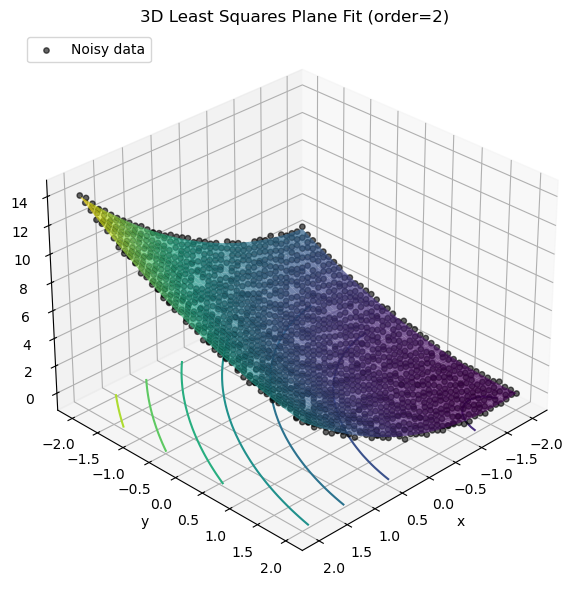

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # Needed for 3D plotting

# -----------------------------------------------------------
# Include your plane_lsf() function definition here
# -----------------------------------------------------------

def test_plane_lsf_3D():
    """
    Test and visualize the plane_lsf() function in 3D.
    """
    # --- 1. Generate synthetic coordinate grid ---
    nx, ny = 40, 40
    x = np.linspace(-2, 2, nx)
    y = np.linspace(-2, 2, ny)
    xcor, ycor = np.meshgrid(x, y)

    # --- 2. True underlying surface (quadratic) ---
    true_coeffs = [3.0, 2.0, -1.5, 0.5, -0.2, 0.3]
    z_true = (true_coeffs[0]
              + true_coeffs[1]*xcor
              + true_coeffs[2]*ycor
              + true_coeffs[3]*xcor**2
              + true_coeffs[4]*xcor*ycor
              + true_coeffs[5]*ycor**2)

    # --- 3. Add Gaussian noise ---
    sigma = 0.1
    np.random.seed(1)
    z_noisy = z_true + sigma * np.random.randn(*z_true.shape)

    # --- 4. Mask a few random points (simulate missing data) ---
    mask_fraction = 0.05
    nan_mask = np.random.rand(*z_noisy.shape) < mask_fraction
    z_noisy[nan_mask] = np.nan

    # --- 5. Fit plane using least squares function ---
    plane_fit, coeffs, coeffs_sigma, L2_norm = plane_lsf(z_noisy, xcor, ycor, parameters=2, sigma=sigma)

    # --- 6. Print results ---
    print("True coefficients:", np.round(true_coeffs, 3))
    print("Estimated coefficients:", np.round(coeffs, 3))
    print("Uncertainties (σ):", np.round(coeffs_sigma, 3))
    print("L2 Norm:", np.round(L2_norm, 3))

    # --- 7. 3D Visualization ---
    fig = plt.figure(figsize=(12, 6))
    ax = fig.add_subplot(111, projection='3d')

    # Plot noisy data as scatter points
    ax.scatter(xcor[~np.isnan(z_noisy)], ycor[~np.isnan(z_noisy)],
               z_noisy[~np.isnan(z_noisy)], color='k', s=15, alpha=0.6, label='Noisy data')

    # Plot fitted surface as wireframe
    ax.plot_surface(xcor, ycor, plane_fit, cmap='viridis', alpha=0.7, rstride=1, cstride=1, linewidth=0)

    # Optionally, plot true surface as contour below
    ax.contour(xcor, ycor, z_true, zdir='z', offset=np.min(z_true)-1, cmap='viridis')

    # Labels and aesthetics
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_zlabel('z')
    ax.set_title('3D Least Squares Plane Fit (order=2)')
    ax.legend(loc='upper left')

    # Adjust view angle for clarity
    ax.view_init(elev=30, azim=45)
    plt.tight_layout()
    plt.show()


# Run test
if __name__ == "__main__":
    test_plane_lsf_3D()
